# Portfolio Analysis Research Methodology

## An End-to-End Portfolio Analysis Project with Python

---

## Project Overview

This project analyzes the historical performance and risk characteristics of a diversified portfolio of U.S. equities using Python.

Using historical market data from Yahoo Finance, the project walks through a complete portfolio analysis workflow from downloading stock prices to calculating returns, measuring portfolio risk, and visualizing the results.

The goal is to combine concepts from statistics, linear algebra, finance, and Python into a practical project that demonstrates how quantitative techniques can be applied to portfolio analysis.

---

## Objectives

Throughout this project, I will:

- Download historical stock price data from Yahoo Finance.
- Calculate daily and cumulative returns.
- Construct a diversified portfolio.
- Compute expected portfolio return and volatility.
- Analyze covariance and correlation between assets.
- Measure portfolio performance using the Sharpe Ratio.
- Visualize portfolio behaviour using charts and statistical graphics.
- Generate thousands of random portfolios using Monte Carlo simulation.
- Explore the risk-return trade-off using an Efficient Frontier approximation.
- Summarize the results in a portfolio dashboard and report.

---

## Tools & Libraries

- **yfinance** -- Download historical market data
- **Pandas** -- Data manipulation and analysis
- **NumPy** -- Numerical computing and matrix operations
- **Matplotlib** -- Data visualization
- **Seaborn** -- Statistical visualization

---

## Portfolio Construction

The portfolio consists of 30 companies selected across multiple sectors of the U.S. economy, including:

- Technology
- Financials
- Healthcare
- Consumer
- Automobiles
- Energy
- Industrials

Rather than concentrating on a single industry, the portfolio is designed to provide exposure to different parts of the market, illustrating the concept of diversification.

---

## Project Workflow

```text
Download Historical Prices
          │
          ▼
Data Validation
          │
          ▼
Return Calculations
          │
          ▼
Portfolio Statistics
          │
          ▼
Risk Analysis
          │
          ▼
Monte Carlo Simulation
          │
          ▼
Efficient Frontier
          │ 
          ▼
Portfolio Dashboard & Report
```

---

**Author:** Rasheedat Seidu

**Roadmap:** Quant Foundations -- Project 1

## Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import seaborn as sns

## Portfolio Construction Strategy

Rather than selecting stocks from a single industry, I constructed a diversified portfolio of **30 U.S. equities** spanning seven major sectors of the economy.

Technology represents the largest allocation due to its significant weight in modern equity markets and its central role in innovation, cloud computing, semiconductors, and artificial intelligence.

To reduce concentration risk, the portfolio also includes companies from the Financials, Healthcare, Consumer, Energy, Industrials, and Automobiles sectors. These sectors are influenced by different economic drivers including interest rates, consumer spending, commodity prices, and business investment which helps improve diversification.

The objective is not to identify the best-performing individual stock, but to construct a portfolio that reflects multiple areas of the U.S. economy while providing a realistic dataset for portfolio risk and performance analysis.

In [2]:
tickers = [
    # Technology
    "AAPL","MSFT","NVDA","AMZN",
    "GOOG","META","AMD","ORCL",

    # Financials
    "JPM","BAC","GS","V","MA",

    # Healthcare
    "JNJ","PFE","LLY","MRK","ABBV",

    # Consumer
    "WMT","COST","PG","KO","MCD",

    # Automobiles
    "TSLA","GM","F",

    # Energy
    "XOM","CVX",

    # Industrials
    "CAT","GE"
]

## Data Acquisition & Validation

The first step in any data analysis project is to obtain reliable data and verify its quality.

In this section, I download five years of historical daily closing prices for a diversified portfolio of 30 U.S. equities using the `yfinance` library. I then perform a series of validation checks including inspecting the dataset, reviewing its structure, confirming its dimensions, and checking for missing values.

In [3]:
start_date = "2020-01-01"
end_date = "2025-01-01"

In [4]:
stock_prices = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

In [5]:
stock_prices = stock_prices["Close"]

In [6]:
stock_prices.index.name = "Date"

In [7]:
print(stock_prices.head())

Ticker           AAPL       ABBV        AMD       AMZN        BAC         CAT  \
Date                                                                            
2020-01-02  72.333885  68.210732  49.099998  94.900497  30.429459  132.067856   
2020-01-03  71.630623  67.563293  48.599998  93.748497  29.797634  130.234222   
2020-01-06  72.201401  68.096481  48.389999  95.143997  29.754953  130.146454   
2020-01-07  71.861855  67.708000  48.250000  95.343002  29.558578  128.426880   
2020-01-08  73.017830  68.187859  47.830002  94.598503  29.857409  129.567429   

Ticker            COST        CVX         F         GE  ...        MRK  \
Date                                                    ...              
2020-01-02  265.326538  91.182571  6.866070  57.675591  ...  71.578629   
2020-01-03  265.544952  90.867203  6.713004  57.868977  ...  70.964264   
2020-01-06  265.617798  90.559326  6.676558  58.690838  ...  71.267555   
2020-01-07  265.199158  89.402916  6.742158  58.255741  ...  6

In [8]:
print(stock_prices.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   ABBV    1258 non-null   float64
 2   AMD     1258 non-null   float64
 3   AMZN    1258 non-null   float64
 4   BAC     1258 non-null   float64
 5   CAT     1258 non-null   float64
 6   COST    1258 non-null   float64
 7   CVX     1258 non-null   float64
 8   F       1258 non-null   float64
 9   GE      1258 non-null   float64
 10  GM      1258 non-null   float64
 11  GOOG    1258 non-null   float64
 12  GS      1258 non-null   float64
 13  JNJ     1258 non-null   float64
 14  JPM     1258 non-null   float64
 15  KO      1258 non-null   float64
 16  LLY     1258 non-null   float64
 17  MA      1258 non-null   float64
 18  MCD     1258 non-null   float64
 19  META    1258 non-null   float64
 20  MRK     1258 non-null   float64
 21  MSFT    1258 non-nu

In [9]:
print(stock_prices.shape)

(1258, 30)


In [10]:
print(stock_prices.isnull().sum())

Ticker
AAPL    0
ABBV    0
AMD     0
AMZN    0
BAC     0
CAT     0
COST    0
CVX     0
F       0
GE      0
GM      0
GOOG    0
GS      0
JNJ     0
JPM     0
KO      0
LLY     0
MA      0
MCD     0
META    0
MRK     0
MSFT    0
NVDA    0
ORCL    0
PFE     0
PG      0
TSLA    0
V       0
WMT     0
XOM     0
dtype: int64


## Calculate Daily Returns

Stock prices alone provide limited insight into investment performance because they are measured on different scales. Comparing a stock trading at **USD 50** to one trading at **USD 500** based solely on price can be misleading.

Instead, portfolio analysis focuses on **returns**, which measure the percentage change in an asset's value over time. Returns standardize performance across assets, making them comparable regardless of their price levels.

In this section, daily percentage returns are calculated for each stock in the portfolio. These returns form the foundation for all subsequent analyses, including cumulative returns, expected portfolio return, portfolio volatility, covariance, correlation, the Sharpe Ratio, Monte Carlo portfolio simulation, and the Efficient Frontier.

In [11]:
daily_returns = stock_prices.pct_change()

In [12]:
daily_returns.head()                                                                                              # Inspect the daily returns DataFrame

Ticker,AAPL,ABBV,AMD,AMZN,BAC,CAT,COST,CVX,F,GE,...,MRK,MSFT,NVDA,ORCL,PFE,PG,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.009492,-0.010183,-0.012139,-0.020764,-0.013884,0.000823,-0.003459,-0.022293,0.003353,...,-0.008583,-0.012452,-0.016006,-0.003522,-0.005365,-0.006725,0.029633,-0.007953,-0.008828,-0.008040
2020-01-06,0.007968,0.007892,-0.004321,0.014886,-0.001432,-0.000674,0.000274,-0.003388,-0.005429,0.014202,...,0.004274,0.002585,0.004194,0.005208,-0.001285,0.001387,0.019255,-0.002162,-0.002036,0.007678
2020-01-07,-0.004703,-0.005705,-0.002893,0.002092,-0.006600,-0.013213,-0.001576,-0.012770,0.009825,-0.007413,...,-0.026626,-0.009118,0.012107,0.002221,-0.003344,-0.006191,0.038801,-0.002643,-0.009265,-0.008184
2020-01-08,0.016086,0.007087,-0.008705,-0.007809,0.010110,0.008881,0.011463,-0.011423,0.000000,-0.009129,...,-0.006726,0.015928,0.001875,0.003895,0.008000,0.004262,0.049205,0.017118,-0.003432,-0.015081


In [13]:
daily_returns = daily_returns.dropna()                                                   # Remove the first row containing NaN values from pct_change()

In [14]:
daily_returns.shape                                                                                             # Verify the updated dataset dimensions

(1257, 30)

### Summary Statistics (Daily Returns)

To better understand the behaviour of each stock, I generated descriptive statistics for the daily return series using the `describe()` function.

The summary provides key measures such as the average daily return (mean), volatility (standard deviation), minimum and maximum daily returns, and the distribution of returns through the quartiles. Together, these metrics provide an initial assessment of each asset's historical performance and risk profile over the five-year period.

Among the 30 stocks, **NVIDIA (NVDA)** recorded the highest average daily return (**0.3050%**), closely followed by **Tesla (TSLA)** (**0.2997%**) and **Eli Lilly (LLY)** (**0.1663%**). At the other end of the portfolio, **Pfizer (PFE)** produced the lowest average daily return (**0.0052%**), while **Johnson & Johnson (JNJ)** and **Coca-Cola (KO)** also exhibited relatively modest average returns. 

To make these differences easier to interpret, the average daily returns were visualized using the bar chart below. This provides a clear comparison of historical performance across all 30 portfolio constituents and highlights which stocks contributed the strongest average daily gains over the analysis period.

In [15]:
daily_returns.describe()

Ticker,AAPL,ABBV,AMD,AMZN,BAC,CAT,COST,CVX,F,GE,...,MRK,MSFT,NVDA,ORCL,PFE,PG,TSLA,V,WMT,XOM
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,...,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,0.001182,0.000839,0.001261,0.000923,0.000518,0.000997,0.001095,0.000570,0.000608,0.001147,...,0.000331,0.000988,0.003050,0.001170,0.000052,0.000429,0.002997,0.000582,0.000816,0.000759
std,0.019956,0.015613,0.033047,0.022655,0.022515,0.020468,0.015210,0.022412,0.028033,0.024819,...,0.014822,0.019211,0.033940,0.020671,0.017306,0.013181,0.042320,0.017566,0.014220,0.021657
min,-0.128647,-0.130022,-0.146390,-0.140494,-0.153974,-0.142822,-0.124513,-0.221248,-0.183614,-0.151592,...,-0.098630,-0.147390,-0.184521,-0.134954,-0.077347,-0.087373,-0.210628,-0.135472,-0.113758,-0.122248
25%,-0.008425,-0.006767,-0.017264,-0.011086,-0.010534,-0.009723,-0.006378,-0.009008,-0.014205,-0.011274,...,-0.006904,-0.008176,-0.015996,-0.007915,-0.009437,-0.005533,-0.020051,-0.007738,-0.005777,-0.010938
50%,0.001187,0.001161,-0.000324,0.000782,0.000214,0.001000,0.001408,0.000807,0.000000,0.000936,...,0.000131,0.001111,0.003291,0.001262,-0.000833,0.000690,0.001871,0.001255,0.000743,0.000234
75%,0.011989,0.008642,0.020103,0.012956,0.010861,0.011762,0.008944,0.009894,0.014656,0.012838,...,0.007810,0.010940,0.022306,0.009881,0.008346,0.006868,0.023769,0.008751,0.007325,0.012087
max,0.119808,0.087174,0.165016,0.135359,0.177962,0.103321,0.099595,0.227407,0.234414,0.147300,...,0.083743,0.142169,0.243696,0.204271,0.108552,0.120090,0.219190,0.138426,0.117085,0.126868


In [16]:
avg_returns = daily_returns.mean().sort_values(
    ascending=False
)

avg_returns  # calculating avg_returns seperately to have 

Ticker
NVDA    0.003050
TSLA    0.002997
LLY     0.001663
AMD     0.001261
META    0.001225
AAPL    0.001182
ORCL    0.001170
GE      0.001147
COST    0.001095
GOOG    0.001026
GS      0.001025
CAT     0.000997
MSFT    0.000988
AMZN    0.000923
ABBV    0.000839
WMT     0.000816
XOM     0.000759
JPM     0.000746
GM      0.000681
MA      0.000651
F       0.000608
V       0.000582
CVX     0.000570
BAC     0.000518
MCD     0.000493
PG      0.000429
MRK     0.000331
KO      0.000308
JNJ     0.000179
PFE     0.000052
dtype: float64

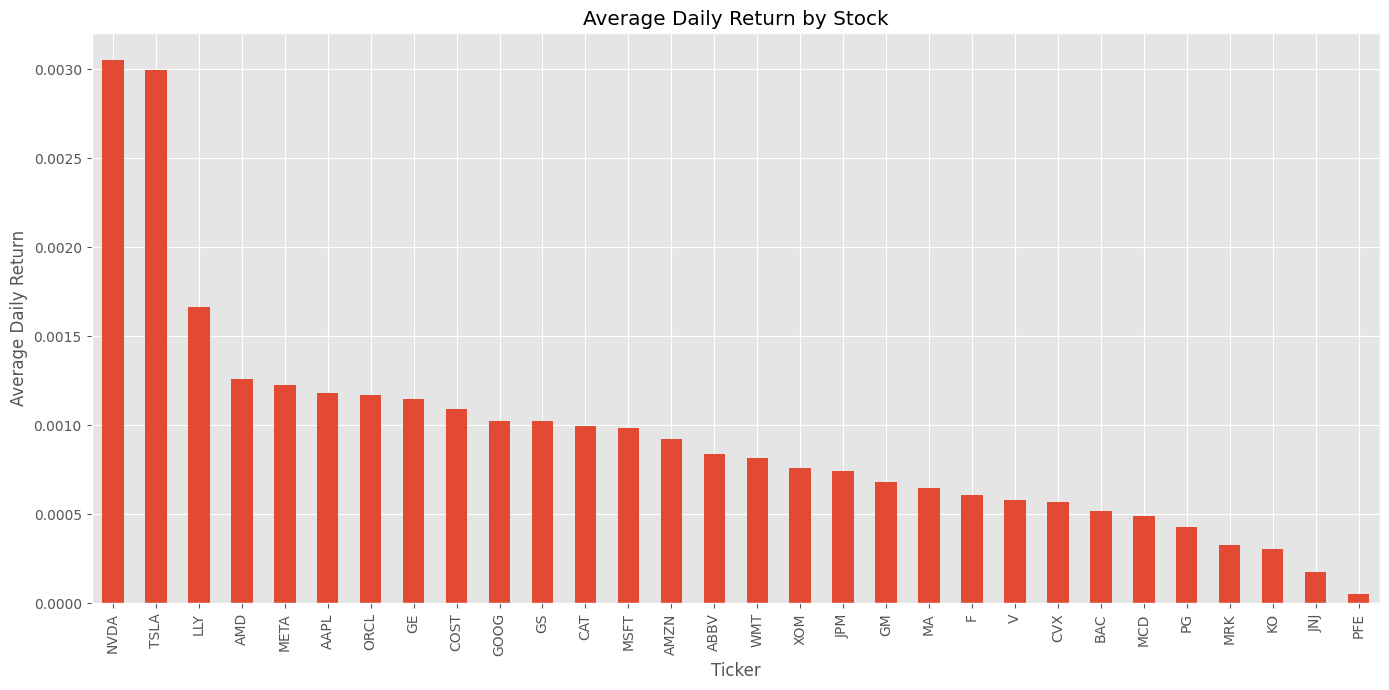

In [17]:
plt.figure(figsize=(14,7))

avg_returns.plot(kind="bar")

plt.title("Average Daily Return by Stock")

plt.ylabel("Average Daily Return")

plt.tight_layout()

plt.show() 

## Cumulative Returns

While daily returns measure the percentage change in an asset's value from one trading day to the next, cumulative returns measure the overall growth of an investment over time.

Cumulative returns assume that gains and losses are continuously reinvested, providing a clearer picture of how an investment would have performed over the analysis period.

This metric is widely used to compare the long-term performance of different assets and serves as an important visualization of portfolio growth.

In [18]:
cumulative_returns = (1 + daily_returns).cumprod()

In [19]:
cumulative_returns.head()

Ticker,AAPL,ABBV,AMD,AMZN,BAC,CAT,COST,CVX,F,GE,...,MRK,MSFT,NVDA,ORCL,PFE,PG,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,0.990278,0.990508,0.989817,0.987861,0.979236,0.986116,1.000823,0.996541,0.977707,1.003353,...,0.991417,0.987548,0.983994,0.996478,0.994635,0.993275,1.029633,0.992047,0.991172,0.991960
2020-01-06,0.998168,0.998325,0.985540,1.002566,0.977834,0.985451,1.001098,0.993165,0.972399,1.017603,...,0.995654,0.990101,0.988120,1.001668,0.993357,0.994652,1.049458,0.989902,0.989154,0.999577
2020-01-07,0.993474,0.992630,0.982688,1.004663,0.971380,0.972431,0.999520,0.980483,0.981953,1.010059,...,0.969144,0.981074,1.000083,1.003892,0.990036,0.988494,1.090178,0.987286,0.979990,0.991396
2020-01-08,1.009455,0.999665,0.974134,0.996818,0.981201,0.981067,1.010978,0.969283,0.981953,1.000838,...,0.962625,0.996701,1.001959,1.007802,0.997956,0.992707,1.143820,1.004186,0.976627,0.976445
2020-01-09,1.030897,1.007370,0.997352,1.001602,0.982884,0.978609,1.027205,0.967718,0.983015,0.998324,...,0.971100,1.009152,1.012963,1.012457,0.993613,1.003566,1.118719,1.011145,0.986716,0.983921


### Analysis of the Top Five Performers

The cumulative return chart highlights the five strongest-performing stocks over the five-year analysis period: **NVIDIA (NVDA), Tesla (TSLA), Eli Lilly (LLY), Apple (AAPL), and Costco (COST)**. While all five generated positive long-term returns, their growth trajectories differed significantly, illustrating the trade-off between return and volatility.

- **NVIDIA (NVDA)** emerged as the portfolio's best-performing stock by a considerable margin. Although it experienced periods of elevated volatility, particularly between 2022 and 2023, its strong recovery and sustained upward momentum resulted in the highest cumulative return by the end of the analysis period.

- **Tesla (TSLA)** exhibited the most volatile price behaviour among the top performers. The stock experienced multiple sharp rallies and significant drawdowns throughout the five years, reflecting its higher risk profile. Despite these fluctuations, Tesla still delivered exceptional long-term growth.

- **Eli Lilly (LLY)** demonstrated a more consistent upward trend with comparatively lower volatility than NVIDIA and Tesla. Its cumulative return increased steadily over time, making it one of the strongest performers while exhibiting a smoother growth trajectory.

- **Apple (AAPL)** delivered stable and sustained growth throughout the analysis period. Although its cumulative return was lower than the three leading stocks, its relatively consistent appreciation illustrates the strength of a mature large-cap technology company.

- **Costco (COST)** also generated solid long-term returns through gradual and consistent growth rather than rapid price appreciation. Its comparatively smoother performance suggests lower variability while still contributing positively to the overall portfolio.

Overall, the chart demonstrates that the highest long-term returns were generally accompanied by greater price fluctuations. Stocks such as NVIDIA and Tesla achieved exceptional growth but experienced substantial periods of volatility, whereas Eli Lilly, Apple, and Costco produced stronger risk-adjusted growth through more stable appreciation. This comparison highlights the importance of evaluating both return and risk when assessing portfolio performance.

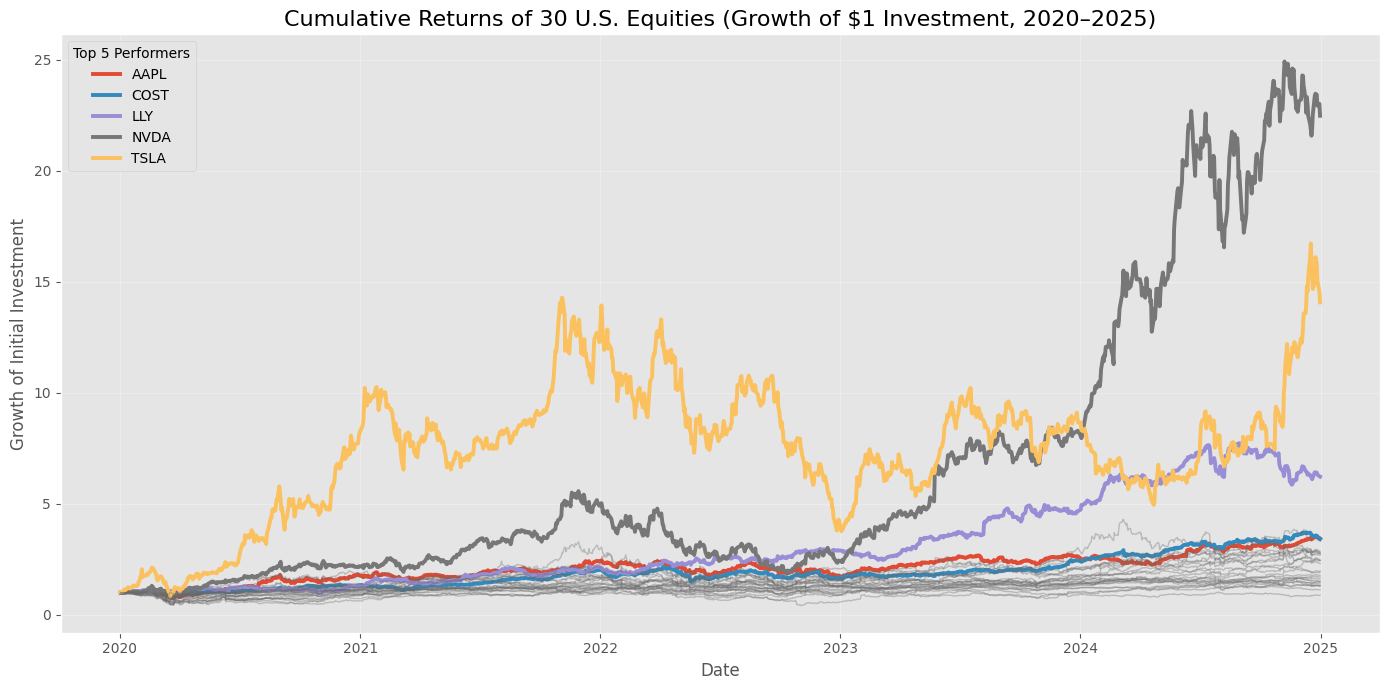

In [20]:
# Identify the top 5 performing stocks based on final cumulative return
top5_stocks = cumulative_returns.iloc[-1].nlargest(5).index

plt.figure(figsize=(14, 7))

for stock in cumulative_returns.columns:
    if stock in top5_stocks:
        plt.plot(
            cumulative_returns.index,
            cumulative_returns[stock],
            linewidth=2.8,
            label=stock
        )
    else:
        plt.plot(
            cumulative_returns.index,
            cumulative_returns[stock],
            color="dimgray",
            alpha=0.35,
            linewidth=1
        )

plt.title("Cumulative Returns of 30 U.S. Equities (Growth of $1 Investment, 2020–2025)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Growth of Initial Investment")
plt.legend(title="Top 5 Performers")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Average Returns Are Not Wealth Creation

Stocks with the highest average daily returns do not necessarily produce the highest cumulative returns. While the arithmetic mean summarizes the average daily performance, cumulative returns are determined by the sequence and compounding of returns over time.

Consequently, two stocks with similar or even identical average daily returns may generate substantially different investment outcomes. This explains why ranking stocks by average daily return can differ from ranking them by cumulative return, which reflects the actual growth of an investment over the analysis period.

## Portfolio Weights

In [21]:
n_assets = len(daily_returns.columns)

n_assets

30

In [22]:
weights = np.ones(n_assets) / n_assets

weights

array([0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333])

In [23]:
weights.sum()

np.float64(1.0)

#### Interpretation

Each stock was assigned an equal portfolio weight of **3.33%**, resulting in a fully invested portfolio with weights summing to **100%**.

An equal-weighted allocation provides a neutral starting point for portfolio analysis by ensuring that no individual stock dominates the portfolio's behaviour. Consequently, differences in portfolio performance arise from the assets' returns and interactions rather than unequal capital allocations.

These portfolio weights will be used throughout the remainder of the analysis to compute expected portfolio return, portfolio volatility, portfolio risk, Monte Carlo simulations, and the Efficient Frontier.

In [24]:
weights_df = pd.DataFrame({
    "Ticker": daily_returns.columns,
    "Weight": weights
})

weights_df

,Ticker,Weight
0,AAPL,0.033333
1,ABBV,0.033333
2,AMD,0.033333
3,AMZN,0.033333
4,BAC,0.033333
5,CAT,0.033333
6,COST,0.033333
7,CVX,0.033333
8,F,0.033333
9,GE,0.033333


## Covariance Matrix

The covariance matrix summarizes how the returns of every pair of stocks move relative to one another over the 5-year analysis period.

Positive covariance indicates that two assets generally move in the same direction, while negative covariance suggests that they tend to move in opposite directions. Values close to zero imply relatively weak co-movement.

The diagonal elements of the covariance matrix represent the variance of each individual stock, whereas the off-diagonal elements measure the covariance between different pairs of stocks.

This matrix is a fundamental component of Modern Portfolio Theory and will be used in the next stage of the analysis to calculate portfolio volatility through the portfolio weights.

#### Interpretation

The covariance matrix reveals how the daily returns of the 30 portfolio constituents move relative to one another over the five-year analysis period.

Several observations are immediately apparent. Technology companies such as **NVIDIA, AMD, Apple, and Microsoft** exhibit relatively high positive covariance, indicating that they frequently respond to similar market and industry factors. Likewise, financial institutions including **Bank of America, JPMorgan Chase, and Goldman Sachs** display stronger covariance with one another, reflecting their shared exposure to interest rate movements and broader economic conditions. A similar pattern is observed for **Chevron** and **ExxonMobil**, whose returns are influenced by fluctuations in energy markets.

Conversely, defensive sectors such as Healthcare and Consumer Staples generally display lower covariance with many of the growth-oriented technology stocks. This weaker co-movement suggests that combining companies from different sectors can improve diversification by reducing the likelihood that all assets experience similar price movements simultaneously.

The covariance matrix therefore provides valuable insight into the interaction between assets and serves as a critical input for portfolio risk measurement. Rather than evaluating stocks individually, it enables analysis of how their combined behaviour influences the overall risk profile of the portfolio.

In [25]:
cov_matrix = daily_returns.cov()

cov_matrix

Ticker,AAPL,ABBV,AMD,AMZN,BAC,CAT,COST,CVX,F,GE,...,MRK,MSFT,NVDA,ORCL,PFE,PG,TSLA,V,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000398,0.000092,0.000370,0.000268,0.000186,0.000143,0.000171,0.000149,0.000205,0.000180,...,0.000089,0.000287,0.000411,0.000196,0.000099,0.000113,0.000408,0.000205,0.000103,0.000122
ABBV,0.000092,0.000244,0.000078,0.000055,0.000125,0.000092,0.000070,0.000133,0.000099,0.000107,...,0.000109,0.000098,0.000098,0.000086,0.000119,0.000085,0.000072,0.000113,0.000061,0.000109
AMD,0.000370,0.000078,0.001092,0.000410,0.000232,0.000204,0.000229,0.000173,0.000300,0.000233,...,0.000061,0.000383,0.000838,0.000267,0.000095,0.000095,0.000614,0.000246,0.000107,0.000125
AMZN,0.000268,0.000055,0.000410,0.000513,0.000144,0.000115,0.000172,0.000083,0.000166,0.000146,...,0.000050,0.000295,0.000446,0.000183,0.000065,0.000069,0.000415,0.000162,0.000096,0.000064
BAC,0.000186,0.000125,0.000232,0.000144,0.000507,0.000301,0.000105,0.000321,0.000368,0.000341,...,0.000109,0.000183,0.000241,0.000194,0.000126,0.000113,0.000265,0.000237,0.000082,0.000290
CAT,0.000143,0.000092,0.000204,0.000115,0.000301,0.000419,0.000094,0.000273,0.000305,0.000294,...,0.000086,0.000138,0.000227,0.000156,0.000099,0.000075,0.000190,0.000177,0.000064,0.000261
COST,0.000171,0.000070,0.000229,0.000172,0.000105,0.000094,0.000231,0.000070,0.000123,0.000101,...,0.000063,0.000170,0.000250,0.000143,0.000073,0.000102,0.000214,0.000119,0.000131,0.000058
CVX,0.000149,0.000133,0.000173,0.000083,0.000321,0.000273,0.000070,0.000502,0.000298,0.000293,...,0.000114,0.000143,0.000191,0.000135,0.000108,0.000074,0.000201,0.000203,0.000060,0.000415
F,0.000205,0.000099,0.000300,0.000166,0.000368,0.000305,0.000123,0.000298,0.000786,0.000361,...,0.000092,0.000191,0.000328,0.000188,0.000098,0.000084,0.000403,0.000228,0.000073,0.000274


In [26]:
cov_matrix.shape                                                                                                              # checking for dimensions

(30, 30)

## Correlation Matrix

While covariance indicates whether two assets move together, its magnitude depends on the volatility of the individual assets. This makes it difficult to compare relationships across different pairs of stocks.

The correlation matrix standardizes covariance, producing values that always lie between **-1** and **+1**. As a result, it provides a clearer measure of the strength and direction of the linear relationship between asset returns.

A correlation close to **+1** indicates that two stocks tend to move together, a value close to **−1** indicates that they generally move in opposite directions, while a correlation near **0** suggests little or no linear relationship.

Because correlation is scale-independent, it is widely used in portfolio construction to identify diversification opportunities and understand how assets interact.

#### Interpretation

The correlation matrix reveals the strength and direction of the linear relationship between the returns of every pair of stocks in the portfolio.

Several distinct sector-based patterns emerge from the analysis. Technology companies including **Apple, Microsoft, NVIDIA, Advanced Micro Devices, Amazon, and Alphabet** exhibit relatively strong positive correlations, reflecting their shared exposure to innovation, artificial intelligence, cloud computing, and broader growth-oriented market sentiment.

Similarly, financial institutions such as **Bank of America, JPMorgan Chase, and Goldman Sachs** display strong correlations, indicating that they respond to similar macroeconomic factors, particularly interest rate movements and economic conditions. A comparable relationship is observed between **Chevron** and **ExxonMobil**, whose returns are heavily influenced by changes in energy prices.

Conversely, companies within Healthcare and Consumer Staples generally exhibit weaker correlations with many technology stocks. These sectors are driven by different economic forces and therefore contribute valuable diversification benefits within the portfolio.

Importantly, no substantial negative correlations are observed, suggesting that while the portfolio is diversified across sectors, all assets remain exposed to the broader U.S. equity market to some extent. Nevertheless, the variation in correlation strengths demonstrates that combining companies from different industries can help reduce overall portfolio risk compared with concentrating investments within a single sector.

In [27]:
corr_matrix = daily_returns.corr()

corr_matrix

Ticker,AAPL,ABBV,AMD,AMZN,BAC,CAT,COST,CVX,F,GE,...,MRK,MSFT,NVDA,ORCL,PFE,PG,TSLA,V,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.296459,0.561703,0.592200,0.413413,0.351076,0.564238,0.333986,0.366153,0.363675,...,0.299494,0.748327,0.606399,0.475265,0.285310,0.429077,0.482701,0.584309,0.363277,0.281849
ABBV,0.296459,1.000000,0.150934,0.154745,0.355961,0.288707,0.292819,0.380589,0.226449,0.276913,...,0.470196,0.325108,0.184475,0.265412,0.440651,0.414350,0.108784,0.412142,0.275777,0.321495
AMD,0.561703,0.150934,1.000000,0.548242,0.311517,0.302115,0.454902,0.233027,0.323921,0.283738,...,0.124831,0.603555,0.746982,0.390806,0.166015,0.218741,0.438843,0.424082,0.227081,0.174294
AMZN,0.592200,0.154745,0.548242,1.000000,0.282753,0.247027,0.499085,0.163465,0.261883,0.260419,...,0.149401,0.678500,0.579744,0.390896,0.164856,0.231636,0.432593,0.405909,0.296760,0.130716
BAC,0.413413,0.355961,0.311517,0.282753,1.000000,0.652932,0.305347,0.635509,0.582438,0.610195,...,0.326943,0.422139,0.314994,0.417753,0.322230,0.381624,0.278083,0.600167,0.255627,0.595731
CAT,0.351076,0.288707,0.302115,0.247027,0.652932,1.000000,0.301758,0.595845,0.531184,0.577972,...,0.284781,0.349893,0.326909,0.369245,0.280762,0.276431,0.219082,0.491732,0.220133,0.589042
COST,0.564238,0.292819,0.454902,0.499085,0.305347,0.301758,1.000000,0.204691,0.289553,0.267005,...,0.281395,0.582624,0.484110,0.455718,0.276872,0.509435,0.332591,0.445639,0.604774,0.175376
CVX,0.333986,0.380589,0.233027,0.163465,0.635509,0.595845,0.204691,1.000000,0.475106,0.525933,...,0.342815,0.331416,0.251499,0.290732,0.277862,0.249095,0.211714,0.516146,0.188069,0.855452
F,0.366153,0.226449,0.323921,0.261883,0.582438,0.531184,0.289553,0.475106,1.000000,0.518340,...,0.221640,0.354374,0.345183,0.324539,0.201313,0.227497,0.339733,0.463789,0.182439,0.451088


In [28]:
corr_matrix.shape

(30, 30)

In [29]:
np.diag(corr_matrix)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### Correlation Heatmap

While the correlation matrix provides the exact numerical relationship between every pair of stocks, a **correlation heatmap** offers a visual representation of these relationships using colour intensity. This makes it much easier to identify patterns, clusters of highly correlated stocks, and potential diversification opportunities within the portfolio. In this analysis, the heatmap is used to complement the correlation matrix by providing an intuitive overview of how the 30 stocks moved relative to one another during the 2020–2025 period.

#### Interpretation

The correlation heatmap provides a visual representation of the relationships between the daily returns of the 30 stocks included in the portfolio over the 2020–2025 study period. Correlation coefficients range from **-1 to +1**, where values close to **+1** indicate that two stocks tend to move together, values near **0** suggest little or no linear relationship, and values close to **-1** indicate that the stocks tend to move in opposite directions.

Several observations can be made from the heatmap:

- The majority of stock pairs exhibit **positive correlations**, indicating that most companies generally moved in the same direction as the broader equity market during the sample period. This is expected, as stocks are often influenced by common macroeconomic factors such as interest rates, inflation, economic growth, and overall market sentiment.

- Technology companies display some of the strongest relationships. For example, **Microsoft (MSFT), Apple (AAPL), NVIDIA (NVDA), Google (GOOG), Amazon (AMZN), and AMD** show relatively high positive correlations, reflecting their exposure to similar industry trends and investor sentiment.

- Financial institutions such as **JPMorgan (JPM), Bank of America (BAC), and Goldman Sachs (GS)** are also highly correlated with one another, as they operate within the same sector and are affected by similar economic and monetary conditions.

- Defensive sectors, including healthcare and consumer staples, generally exhibit lower correlations with many of the technology and cyclical stocks. Companies such as **Johnson & Johnson (JNJ), Pfizer (PFE), Merck (MRK), Procter & Gamble (PG), and Walmart (WMT)** display comparatively weaker relationships, highlighting the diversification benefits they can provide within the portfolio.

- Importantly, **no strong negative correlations** are observed in the dataset. This indicates that while diversification exists through varying degrees of positive correlation, the portfolio does not contain assets that consistently move in opposite directions. Such behaviour is common in equity-only portfolios, where stocks are generally influenced by the same market-wide factors.

Overall, the heatmap suggests that the portfolio achieves diversification primarily by combining companies from different industries rather than relying on negatively correlated assets. This insight complements the covariance matrix analysed earlier and helps explain why portfolio volatility can be reduced through diversification, even when most individual assets remain positively correlated.

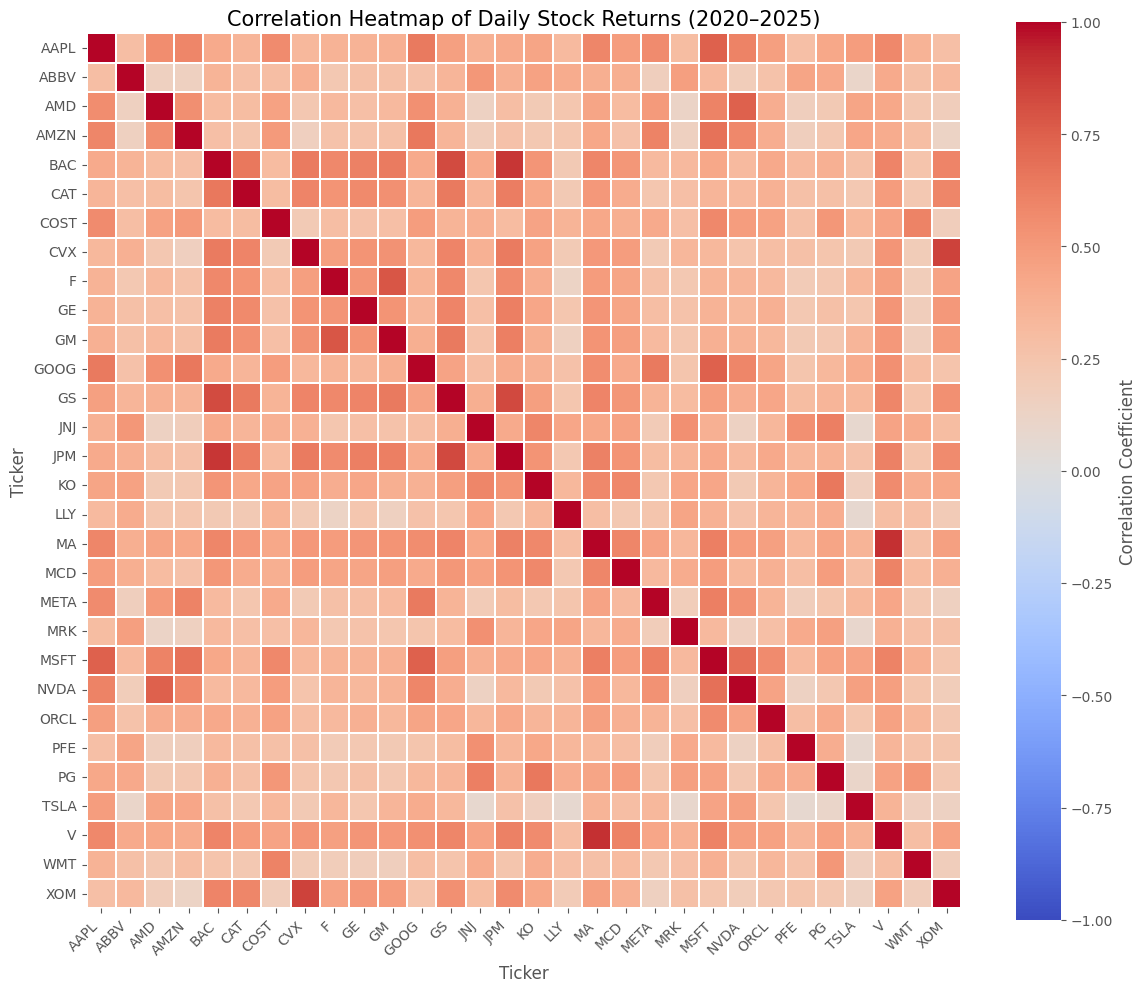

In [30]:
corr_matrix = daily_returns.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,           
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot=False,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Heatmap of Daily Stock Returns (2020–2025)", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Expected Portfolio Return

The expected portfolio return represents the weighted average return of all assets in the portfolio.

Rather than treating every stock equally, each company's contribution depends on its portfolio allocation. Assets with larger weights have a greater influence on the portfolio's overall expected performance.

Mathematically, the expected portfolio return is computed as the dot product of the portfolio weight vector and the vector of mean daily returns.

This metric provides an estimate of the average daily return that an investor could expect if historical return patterns were to persist. Although past performance does not guarantee future results, expected return serves as a fundamental input for portfolio optimisation and risk-return analysis.

#### Interpretation

The portfolio generated an **expected daily return of approximately 0.0944%**, based on the historical average daily returns of its 30 constituent stocks over the five-year analysis period.

Annualising this figure using **252 trading days** produces an **expected annual return of approximately 23.78%**. This suggests that, if historical average returns were to persist, the portfolio could be expected to earn roughly **23.8% per year** before accounting for transaction costs, taxes, or changes in market conditions.

The relatively high expected return is likely influenced by the strong historical performance of several growth-oriented holdings, particularly **NVIDIA, Tesla, Meta, Advanced Micro Devices (AMD), and Eli Lilly**, which experienced exceptional gains during the analysis period. As such, this estimate should be interpreted with caution, as periods of unusually strong market performance may not be representative of future returns.

It is important to recognise that this is **not a prediction of future performance**. Rather, it is a historical estimate derived from past market data. Future returns may differ significantly as market conditions, economic cycles, and company fundamentals evolve over time.

The expected portfolio return provides a useful benchmark for evaluating portfolio performance and will be used alongside portfolio volatility and the Sharpe Ratio to assess whether the portfolio's returns adequately compensate for the level of risk undertaken.

In [31]:
expected_return = np.dot(weights, avg_returns)

print(f"Expected Daily Portfolio Return: {expected_return:.4%}")

Expected Daily Portfolio Return: 0.0944%


In [32]:
annual_return = expected_return * 252

print(f"Expected Annual Portfolio Return: {annual_return:.2%}")

Expected Annual Portfolio Return: 23.78%


In [33]:
portfolio_return = pd.DataFrame({
    "Metric": [
        "Expected Daily Return",
        "Expected Annual Return"
    ],
    "Value": [
        expected_return,
        annual_return
    ]
})

portfolio_return

,Metric,Value
0,Expected Daily Return,0.000944
1,Expected Annual Return,0.237825


## Portfolio Volatility

Expected return tells us how much a portfolio is expected to earn, but it does not reveal the level of uncertainty associated with those returns.

Portfolio volatility measures the overall risk of a portfolio by quantifying how much its returns fluctuate over time. Unlike the volatility of a single asset, portfolio volatility depends not only on the risk of each individual stock but also on how the assets move relative to one another.

This is why the covariance matrix is essential. Stocks that do not move perfectly together provide diversification benefits, which can reduce the portfolio's overall risk even when individual assets are volatile.

Portfolio volatility is one of the most widely used risk measures in finance and forms the foundation for risk-adjusted performance metrics such as the Sharpe Ratio, Monte Carlo Simulation, and Efficient Frontier analysis.

#### Interpretation

The portfolio recorded a **daily volatility of approximately 1.35%**, which annualises to **21.40%** over 252 trading days. This indicates that the portfolio experienced a moderate-to-high level of return variability during the five-year analysis period.

When viewed alongside the **expected annual return of 23.78%**, the results suggest that the portfolio has historically delivered attractive returns while maintaining a level of risk that is broadly consistent with an equity portfolio containing growth-oriented companies.

This level of volatility is not surprising given the portfolio's composition. Several holdings including **NVIDIA, Tesla, Advanced Micro Devices (AMD), Meta, and Amazon** are recognised for their higher price fluctuations and were also among the strongest contributors to historical returns. These companies naturally increase the portfolio's overall risk profile.

However, the portfolio is not solely composed of high-growth technology stocks. It also includes more defensive companies such as **Johnson & Johnson, Procter & Gamble, Coca-Cola, Walmart, and Pfizer**, as well as exposure to Financials, Energy, Industrials, and Consumer sectors. Earlier correlation analysis showed that many holdings do not move perfectly together, meaning diversification helps offset part of the additional risk introduced by the more volatile growth stocks.

Overall, the results suggest that the portfolio has achieved a reasonable balance between return and risk. While an expected annual return of **23.78%** is accompanied by an annual volatility of **21.40%**, the portfolio's diversification has helped prevent overall risk from rising to the level of its most volatile individual holdings. 

In [34]:
portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(cov_matrix, weights))
)

print(f"Daily Portfolio Volatility: {portfolio_volatility:.4%}")

Daily Portfolio Volatility: 1.3480%


In [35]:
annual_volatility = portfolio_volatility * np.sqrt(252)

print(f"Annual Portfolio Volatility: {annual_volatility:.2%}")

Annual Portfolio Volatility: 21.40%


In [36]:
portfolio_risk = pd.DataFrame({
    "Metric": [
        "Daily Portfolio Volatility",
        "Annual Portfolio Volatility"
    ],
    "Value": [
        portfolio_volatility,
        annual_volatility
    ]
})

portfolio_risk

,Metric,Value
0,Daily Portfolio Volatility,0.013480
1,Annual Portfolio Volatility,0.213993


## Rolling Volatility

Rolling volatility measures how the portfolio's risk changes over time by calculating the annualized standard deviation of returns within a moving 30-day window. Unlike overall portfolio volatility, which provides a single average estimate of risk across the entire five-year period, rolling volatility captures periods of increasing or decreasing market uncertainty.

Periods where the rolling volatility rises indicate that portfolio returns became more variable, reflecting heightened market turbulence or increased uncertainty. Conversely, declining rolling volatility suggests that market conditions became more stable and portfolio returns exhibited less day-to-day fluctuation.

Monitoring rolling volatility provides valuable insight into the dynamic nature of portfolio risk and helps identify episodes where investors were exposed to unusually high or unusually low levels of market volatility.

#### Interpretation

Rolling volatility measures how the portfolio's risk evolves over time by calculating the annualized standard deviation of returns within a moving 30-day window. Unlike the overall portfolio volatility, which provides a single average estimate of risk across the entire five-year period, rolling volatility reveals when the portfolio experienced periods of unusually high or low market uncertainty.

A 30-day rolling window was intentionally selected because it is widely used in financial analysis to monitor short-term changes in portfolio risk while remaining responsive to significant market events. Compared with longer windows such as 90 or 252 trading days, a 30-day window captures sudden shifts in market conditions more clearly, making it particularly effective for identifying episodes of elevated volatility.

The portfolio recorded an average annualized rolling volatility of **18.10%**, indicating that risk was generally moderate throughout most of the five-year analysis period. However, the highest observed rolling volatility reached 85.03%, reflecting an exceptional period of market instability.

This pronounced spike occurred during the early months of 2020, coinciding with the onset of the COVID-19 pandemic. The global health crisis triggered widespread uncertainty, sharp declines in equity markets, and unusually large day-to-day price movements across nearly all sectors. Although I also examined a 90-day rolling window, the volatility spike remained evident only smoother confirming that the elevated risk was driven by genuine market conditions rather than the choice of rolling window.

As financial markets gradually recovered, portfolio volatility declined substantially and remained relatively stable for much of the remaining sample period. The lowest recorded rolling volatility of **6.42%** reflects periods of comparatively calm market conditions, during which daily portfolio returns exhibited much smaller fluctuations.

These findings are consistent with the earlier portfolio analysis. The portfolio generated an expected annual return of approximately **23.78%**, maintained a long-run annualized volatility of **21.40%**, and experienced a maximum drawdown of **33.24%** during the five-year investment horizon. The rolling volatility analysis adds an important dimension by demonstrating that portfolio risk is dynamic rather than constant, increasing sharply during periods of market stress and declining as conditions stabilize.

Overall, this analysis highlights why rolling volatility is an essential portfolio risk metric. Rather than relying solely on a single historical volatility estimate, it provides a continuous view of how investment risk changes through time, enabling investors and portfolio managers to better understand and respond to evolving market conditions.

In [37]:
portfolio_returns = daily_returns.dot(weights)         # Compute the portfolio's daily returns using the weighted average of individual stock returns

In [38]:
# Calculate the portfolio's rolling annualized volatility using a 30-day moving window
rolling_volatility = portfolio_returns.rolling(window=30).std() * np.sqrt(252)
rolling_volatility = rolling_volatility.dropna()

In [39]:
# Display the first few observations
rolling_volatility.head()

Date
2020-02-14    0.121796
2020-02-18    0.118167
2020-02-19    0.119492
2020-02-20    0.120285
2020-02-21    0.126819
dtype: float64

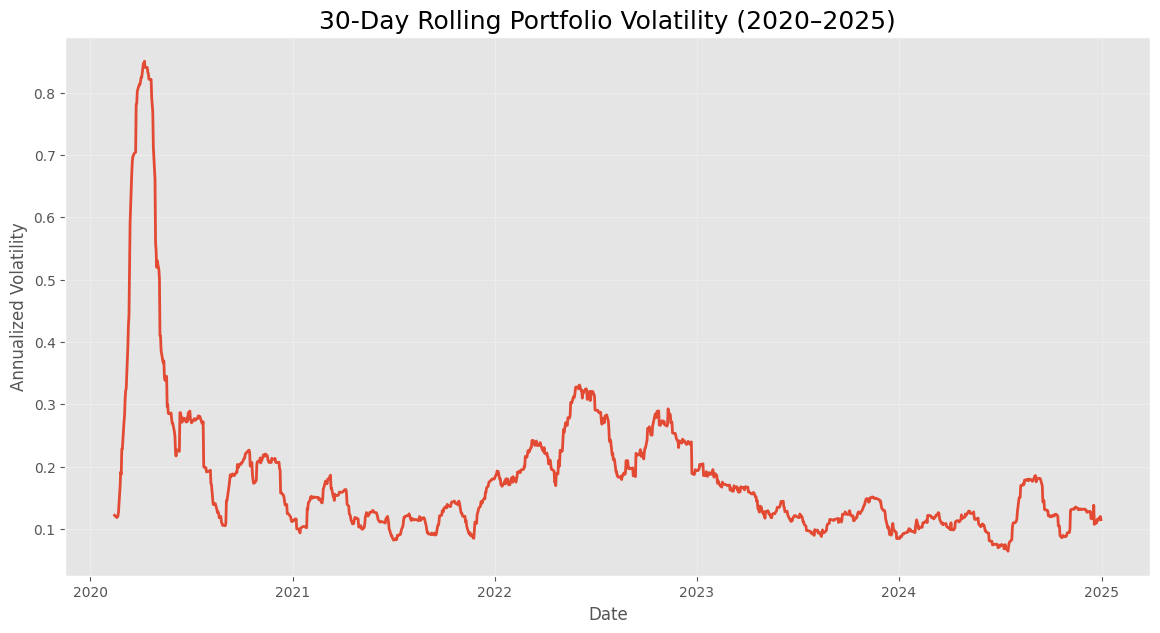

In [40]:
plt.figure(figsize=(14,7))

plt.plot(
    rolling_volatility,
    linewidth=2
)

plt.title("30-Day Rolling Portfolio Volatility (2020–2025)", fontsize=18)

plt.xlabel("Date")

plt.ylabel("Annualized Volatility")

plt.grid(alpha=0.3)

plt.show()

In [41]:
volatility_summary = pd.DataFrame({
    "Metric": [
        "Average Rolling Volatility",
        "Highest Rolling Volatility",
        "Lowest Rolling Volatility"
    ],
    "Value": [
        rolling_volatility.mean(),
        rolling_volatility.max(),
        rolling_volatility.min()
    ]
})

volatility_summary

,Metric,Value
0,Average Rolling Volatility,0.180992
1,Highest Rolling Volatility,0.850280
2,Lowest Rolling Volatility,0.064214


## Drawdown Analysis

Volatility measures the variability of returns, but it does not indicate the magnitude of losses experienced by an investor.

Drawdown measures the percentage decline of a portfolio from its previous highest value (peak) to its subsequent lowest value (trough). It is one of the most practical risk measures because it reflects the temporary losses an investor would have experienced before the portfolio recovered.

Unlike volatility, which captures fluctuations in both directions, drawdown focuses exclusively on downside risk. Larger drawdowns generally indicate greater portfolio risk and longer recovery periods.

Portfolio managers frequently monitor maximum drawdown alongside volatility to evaluate how resilient a portfolio is during periods of market stress.

#### Interpretation

The drawdown chart measures the decline in the portfolio's value from its previous highest point over time. Unlike volatility, which captures the variability of returns, drawdown focuses on the magnitude of losses experienced before the portfolio recovers to a new peak.

The portfolio recorded a maximum drawdown of approximately **33.24%** during the five-year period. This indicates that an investor who entered the portfolio at its previous peak would have experienced a temporary decline of about one-third of their investment before recovery.

Given the analysis period includes the **COVID-19 market crash, the 2022 bear market, and a period of rapidly rising interest rates**, a maximum drawdown of this magnitude is broadly consistent with a diversified portfolio containing a significant allocation to growth-oriented technology stocks such as **NVIDIA, Tesla, AMD, Microsoft, and Apple**.

Although the portfolio experienced periods of substantial losses, the drawdown curve also shows repeated recoveries toward zero, indicating that the portfolio consistently established new highs over time. This behaviour suggests resilience despite exposure to periods of elevated market volatility.

In [42]:
portfolio_cumulative = (1 + portfolio_returns).cumprod()           # Convert daily returns into cumulative portfolio growth (growth of a $1 investment)

In [43]:
running_max = portfolio_cumulative.cummax()                                    # Track the portfolio's highest value achieved up to each point in time

In [44]:
portfolio_drawdown = (
    portfolio_cumulative - running_max
) / running_max                                                                   # Calculate the percentage decline from the portfolio's previous peak

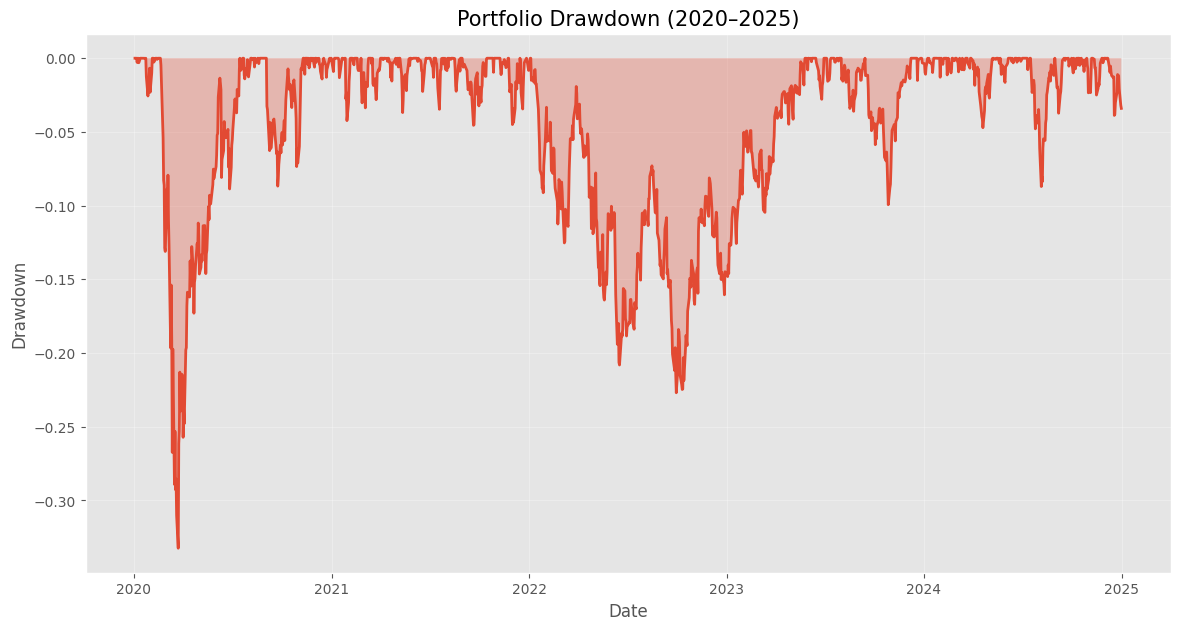

In [45]:
plt.figure(figsize=(14,7))

plt.plot(portfolio_drawdown, linewidth=2)

plt.fill_between(
    portfolio_drawdown.index,
    portfolio_drawdown,
    0,
    alpha=0.3
)

plt.title("Portfolio Drawdown (2020–2025)", fontsize=15)

plt.ylabel("Drawdown")

plt.xlabel("Date")

plt.grid(alpha=0.3)

plt.show()

In [46]:
max_drawdown = portfolio_drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")                                                     # Identify the portfolio's worst historical drawdown

Maximum Drawdown: -33.24%


## Sharpe Ratio

The Sharpe Ratio measures the portfolio's risk-adjusted performance by comparing the portfolio's excess return above the risk-free rate with the level of volatility required to generate that return.

Unlike expected return or volatility alone, the Sharpe Ratio evaluates whether the additional return earned by the portfolio adequately compensates investors for the level of risk undertaken. A higher Sharpe Ratio indicates greater return per unit of risk and is therefore preferred by investors and portfolio managers.

For this analysis, an **annual risk-free rate of 4%** was assumed, representing the approximate yield on **short-term U.S. Treasury securities** during recent market conditions.

#### Interpretation

The portfolio achieved a **Sharpe Ratio of 0.924**, meaning it generated approximately **0.92 units of excess return for every unit of risk undertaken**, after accounting for the assumed **4% annual risk-free rate**.

This indicates that the portfolio delivered positive risk-adjusted performance, although it falls just below the commonly accepted benchmark of 1.0, which is generally regarded as the threshold for good risk-adjusted returns. In practice, this suggests that while the portfolio successfully compensated investors for taking risk, there is still room to improve the balance between return and volatility.

This result is consistent with the portfolio's earlier performance metrics. The portfolio produced an **expected annual return of 23.78%**, accompanied by an **annualized volatility of 21.40%**. Although the return was relatively strong, periods of elevated market uncertainty including the **COVID-19 market crash**, reflected in the rolling volatility analysis and the **33.24% maximum drawdown** increased the portfolio's overall risk, thereby reducing its Sharpe Ratio.

Overall, a **Sharpe Ratio of 0.924** suggests that the portfolio performed reasonably well over the five-year investment horizon, particularly given the challenging market conditions captured in the dataset. However, it also indicates that the current allocation may not be the most efficient combination of assets. This naturally motivates the next stages of the analysis which are **Monte Carlo Simulation** and the **Efficient Frontier** which aim to identify alternative portfolio weightings capable of achieving a higher expected return for the same level of risk, or a lower level of risk for the same expected return.


In [47]:
portfolio_return = portfolio_returns.mean() * 252
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

In [48]:
portfolio_return, portfolio_volatility

(np.float64(0.2378248422212046), np.float64(0.21399298315033974))

In [49]:
# Annual risk-free rate
risk_free_rate = 0.04

# Compute the portfolio's Sharpe Ratio
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

sharpe_ratio

np.float64(0.9244454622244491)

In [50]:
sharpe_summary = pd.DataFrame({
    "Metric": ["Portfolio Sharpe Ratio"],
    "Value": [sharpe_ratio]
})

sharpe_summary

,Metric,Value
0,Portfolio Sharpe Ratio,0.924445


In [51]:
equal_weighted_portfolio = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio 
    ]
})

equal_weighted_portfolio

,Metric,Value
0,Expected Annual Return,0.237825
1,Annual Volatility,0.213993
2,Sharpe Ratio,0.924445


## Monte Carlo Portfolio Simulation


To explore the range of possible portfolio allocations, a Monte Carlo simulation of **10,000 randomly generated portfolios** was performed. Each portfolio was assigned a different combination of weights while ensuring that the total allocation summed to 100%. For every simulated portfolio, the **expected annual return**, **annualized volatility**, and **Sharpe Ratio** were calculated.

The scatter plot illustrates the trade-off between **risk (annualized volatility)** and **expected return**, with each point representing a unique portfolio allocation. The colour scale represents the **Sharpe Ratio**, where lighter colours indicate portfolios delivering higher risk-adjusted returns.

The simulation reveals a clear positive relationship between risk and return. Portfolios with higher expected returns generally require accepting greater levels of volatility, reflecting one of the fundamental principles of **Modern Portfolio Theory (MPT)**.


#### Interpretation

Among the **10,000 simulated portfolios**, the portfolio with the highest risk-adjusted return achieved the following performance:

| Metric | Value |
|:-------------------------|------:|
| Expected Annual Return | **29.53%** |
| Annualized Volatility | **22.60%** |
| Sharpe Ratio | **1.13** |

----
#### Comparison with the Equal-Weight Portfolio

| Portfolio | Expected Return | Annualized Volatility | Sharpe Ratio |
|:---------------------------|-----------------:|-----------------------:|-------------:|
| Equal-Weight Portfolio | **23.78%** | **21.40%** | **0.92** |
| Optimal Monte Carlo Portfolio | **29.53%** | **22.60%** | **1.13** |

----
The Monte Carlo simulation demonstrates that **portfolio allocation plays a crucial role in investment performance**. While the original equal-weight portfolio delivered a respectable annual return of **23.78%** with an annualized volatility of **21.40%**, the optimization process identified an alternative allocation capable of achieving a **29.53% expected annual return** while increasing volatility by only **1.2 percentage points**.

This improvement translated into a Sharpe Ratio increase from **0.92** to **1.13**, indicating that the optimized portfolio generated substantially more return for each unit of risk undertaken. Rather than simply increasing portfolio risk, the simulation identified weight combinations that produced a more efficient balance between return and volatility.

Overall, the Monte Carlo simulation demonstrates the practical value of portfolio optimization. Instead of allocating capital equally across all assets, investors can improve portfolio efficiency by strategically adjusting asset weights to maximise expected returns relative to risk.

In [52]:
np.random.seed(18)
num_portfolios = 10000

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):

    # Generate random portfolio weights
    weights = np.random.random(len(daily_returns.columns))
    weights /= np.sum(weights)

    weights_record.append(weights)

    # Expected annual return
    sim_return = np.sum(weights * daily_returns.mean()) * 252

    # Annual portfolio volatility
    sim_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(daily_returns.cov() * 252, weights)
        )
    )

    # Sharpe Ratio
    sim_sharpe = (sim_return - risk_free_rate) / sim_volatility

    # Store results
    results[0, i] = sim_return
    results[1, i] = sim_volatility
    results[2, i] = sim_sharpe

In [53]:
simulation_results = pd.DataFrame({
    "Return": results[0],
    "Volatility": results[1],
    "Sharpe Ratio": results[2]
})

simulation_results.head()

,Return,Volatility,Sharpe Ratio
0,0.254488,0.224425,0.955720
1,0.257086,0.215053,1.009451
2,0.257189,0.229879,0.944797
3,0.227402,0.210146,0.891772
4,0.231315,0.208562,0.917307


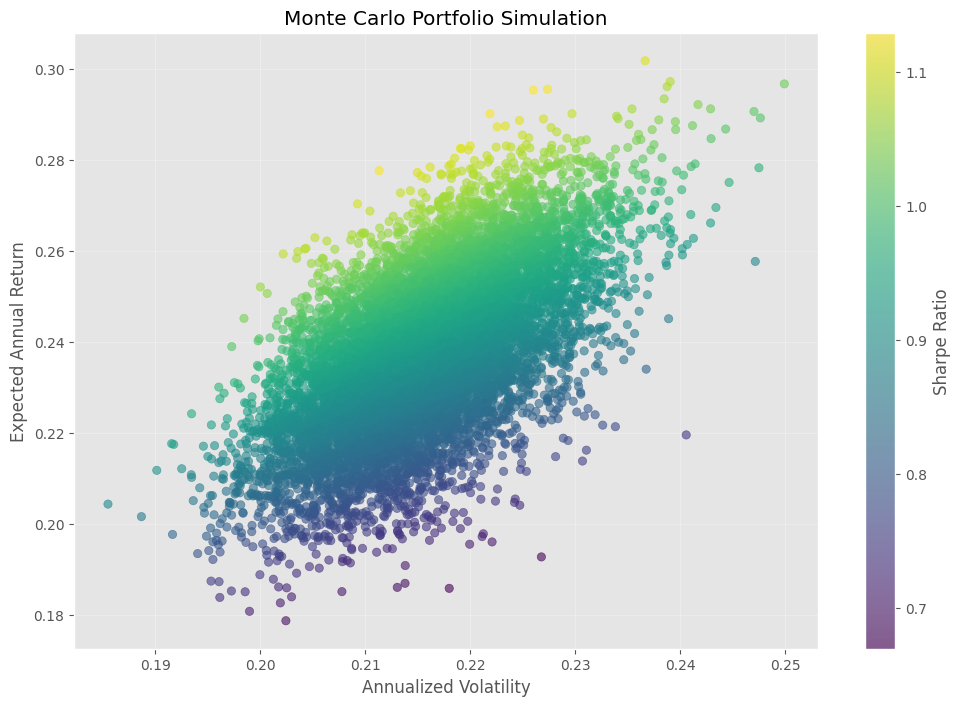

In [54]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    simulation_results["Volatility"],
    simulation_results["Return"],
    c=simulation_results["Sharpe Ratio"],
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")

plt.title("Monte Carlo Portfolio Simulation")

plt.grid(alpha=0.3)

plt.show()

In [55]:
optimized_portfolio = simulation_results.loc[
    simulation_results["Sharpe Ratio"].idxmax()
]

optimized_portfolio = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        optimized_portfolio["Return"],
        optimized_portfolio["Volatility"],
        optimized_portfolio["Sharpe Ratio"]
    ]
})

optimized_portfolio

,Metric,Value
0,Expected Annual Return,0.295288
1,Annual Volatility,0.226013
2,Sharpe Ratio,1.129527


## Efficient Frontier

The Efficient Frontier represents the set of portfolios that offer the highest expected return for a given level of risk, or equivalently, the lowest possible risk for a given level of expected return. It is one of the central concepts of Modern Portfolio Theory introduced by Harry Markowitz.

Using the results from the Monte Carlo simulation, the Efficient Frontier illustrates the trade-off between portfolio risk and return across thousands of feasible portfolio allocations. Portfolios lying below the frontier are considered inefficient because another portfolio exists that either offers a higher expected return for the same level of risk or achieves the same return with lower risk.

The analysis also identifies two important portfolios:

- Maximum Sharpe Portfolio: The portfolio with the highest risk-adjusted return.
- Minimum Volatility Portfolio: The portfolio with the lowest level of portfolio risk.

Together, these portfolios provide useful benchmarks for evaluating the performance of the original equal-weight portfolio.

#### Interpretation

The Efficient Frontier represents the set of portfolios that offer the **highest expected return for a given level of risk**. Each point on the scatter plot corresponds to one of the **100,000 simulated portfolios**, while the colour scale indicates the Sharpe Ratio, with lighter colours representing more attractive risk-adjusted returns.

Two portfolios are highlighted:

- **Maximum Sharpe Portfolio (Red Star):** The portfolio with the highest risk-adjusted return.
- **Minimum Volatility Portfolio (Blue Star):** The portfolio with the lowest level of overall portfolio risk.

----
#### Portfolio Comparison

| Portfolio | Expected Return | Annualized Volatility | Sharpe Ratio |
|:----------------------------|-----------------:|-----------------------:|-------------:|
| Maximum Sharpe Portfolio | **29.53%** | **22.60%** | **1.13** |
| Minimum Volatility Portfolio | **20.44%** | **18.55%** | **0.89** |

----
The Efficient Frontier clearly illustrates the trade-off between **risk and return**. Portfolios located toward the upper-left region of the graph provide more attractive combinations of return and volatility, while portfolios farther below the frontier are comparatively inefficient because similar levels of risk could achieve higher expected returns.

The **Maximum Sharpe Portfolio** emerged as the most efficient allocation among the 100,000 simulated portfolios. It delivers an expected annual return of **29.53%** with an annualized volatility of **22.60%**, resulting in a Sharpe Ratio of **1.13**. Compared with the original equal-weight portfolio (**23.78% return, 21.40% volatility, Sharpe Ratio of 0.92**), the optimized portfolio produces a substantially higher expected return while requiring only a modest increase in portfolio risk.

Conversely, the **Minimum Volatility Portfolio** prioritizes capital preservation by reducing annualized volatility to **18.55%**. This lower-risk allocation comes at the expense of expected return, which decreases to **20.44%** annually. Such a portfolio may be more suitable for conservative investors who are willing to sacrifice higher returns in exchange for greater portfolio stability.

The optimization process also reveals that the highest-performing portfolio is **not equally weighted**. Instead, the algorithm allocated larger weights to companies that historically improved the portfolio's overall risk-return profile while assigning relatively smaller weights to stocks that contributed less efficiently.

The largest allocations in the optimal portfolio include:

- **Apple (AAPL): 7.33%**
- **Exxon Mobil (XOM): 7.26%**
- **Costco (COST): 7.13%**
- **Meta Platforms (META): 7.11%**
- **Amazon (AMZN): 6.67%**

These companies collectively contributed to a portfolio that achieved superior risk-adjusted performance over the five-year study period. Importantly, this allocation is **not based solely on the highest historical returns**. Instead, it reflects how each stock interacted with every other asset through their expected returns, volatilities, and correlations, allowing the optimizer to construct a more efficient portfolio.

Overall, the Efficient Frontier demonstrates the central objective of Modern Portfolio Theory: **an investor's return depends not only on the assets selected, but also on how capital is allocated among them.** Through portfolio optimization, it is possible to improve expected performance without taking proportionally greater levels of risk.

In [56]:
# Portfolio with highest Sharpe Ratio
max_sharpe = simulation_results.loc[
    simulation_results["Sharpe Ratio"].idxmax()
]

# Portfolio with minimum volatility
min_volatility = simulation_results.loc[
    simulation_results["Volatility"].idxmin()
]

In [57]:
max_sharpe

Return          0.295288
Volatility      0.226013
Sharpe Ratio    1.129527
Name: 6935, dtype: float64

In [58]:
min_volatility

Return          0.204390
Volatility      0.185477
Sharpe Ratio    0.886311
Name: 9434, dtype: float64

### Portfolio Allocation

The Monte Carlo simulation identified an optimal asset allocation that maximised the portfolio's risk-adjusted performance. The chart below illustrates the portfolio weights assigned to each security.

Unlike an equally weighted portfolio, the optimisation process allocates different proportions of capital to individual assets based on their contribution to the overall portfolio's expected return and risk profile. Higher weights indicate securities that contributed more favourably to portfolio efficiency, while the distribution of weights demonstrates the benefits of diversification across multiple holdings.

#### Interpretation

The optimal portfolio allocation indicates that the optimisation process did not distribute capital equally across all securities. Instead, larger portfolio weights were assigned to assets that contributed more favourably to the portfolio's expected return relative to its overall level of risk.

Apple (AAPL) received the highest allocation, followed closely by Exxon Mobil (XOM), Costco (COST), and Meta (META), suggesting that these securities provided the most attractive contribution to the portfolio's risk-adjusted performance within the simulation. Although several companies received larger allocations, no single asset dominated the portfolio, reflecting the optimisation model's emphasis on diversification rather than concentration.

Overall, the allocation demonstrates one of the fundamental principles of Modern Portfolio Theory: an efficient portfolio is achieved by selecting a combination of assets that collectively maximise expected return for a given level of risk, rather than relying on individual high-performing securities alone.

In [59]:
best_weights = (
    pd.Series(
        weights_record[
            simulation_results["Sharpe Ratio"].idxmax()
        ],
        index=daily_returns.columns,
        name="Weight"
    )
    .sort_values(ascending=False)
    * 100
)

best_weights

Ticker
AAPL    7.334679
XOM     7.255181
COST    7.125144
META    7.107763
AMZN    6.666059
WMT     5.950960
NVDA    5.841555
TSLA    5.819892
ABBV    5.277350
ORCL    5.231925
F       5.057245
MA      4.942286
LLY     4.645180
MRK     3.491046
MSFT    2.938932
MCD     2.800124
V       2.766483
GE      1.836515
AMD     1.666562
GOOG    1.200410
GM      0.949224
KO      0.901451
GS      0.872847
JPM     0.603568
PG      0.462749
CAT     0.343868
BAC     0.305213
CVX     0.304550
PFE     0.234363
JNJ     0.066877
Name: Weight, dtype: float64

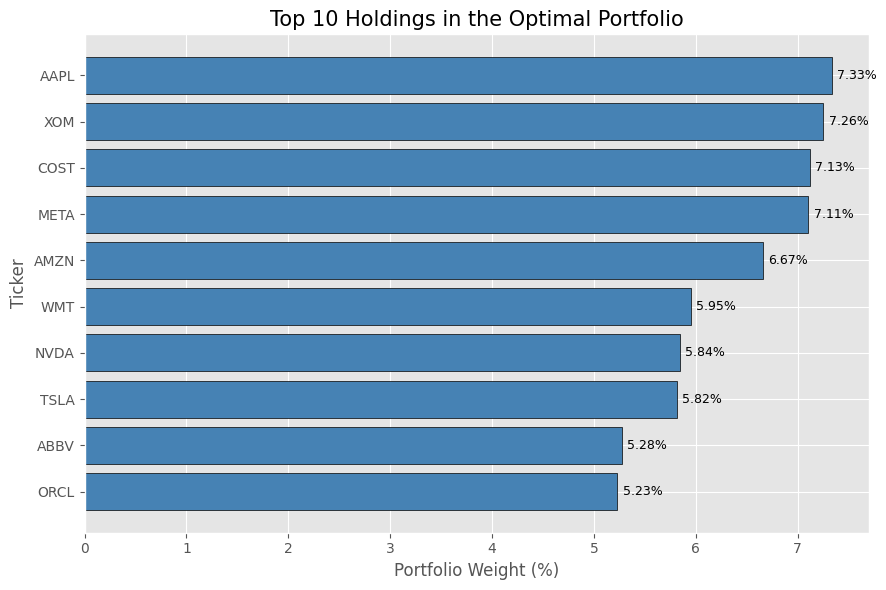

In [60]:
top10 = best_weights.sort_values(ascending=True).tail(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top10.index,
    top10.values,
    color="steelblue",
    edgecolor="black"
)

for i, value in enumerate(top10.values):
    plt.text(
        value + 0.05,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

plt.title(
    "Top 10 Holdings in the Optimal Portfolio",
    fontsize=15
)

plt.xlabel("Portfolio Weight (%)")
plt.ylabel("Ticker")

plt.tight_layout()

plt.show()

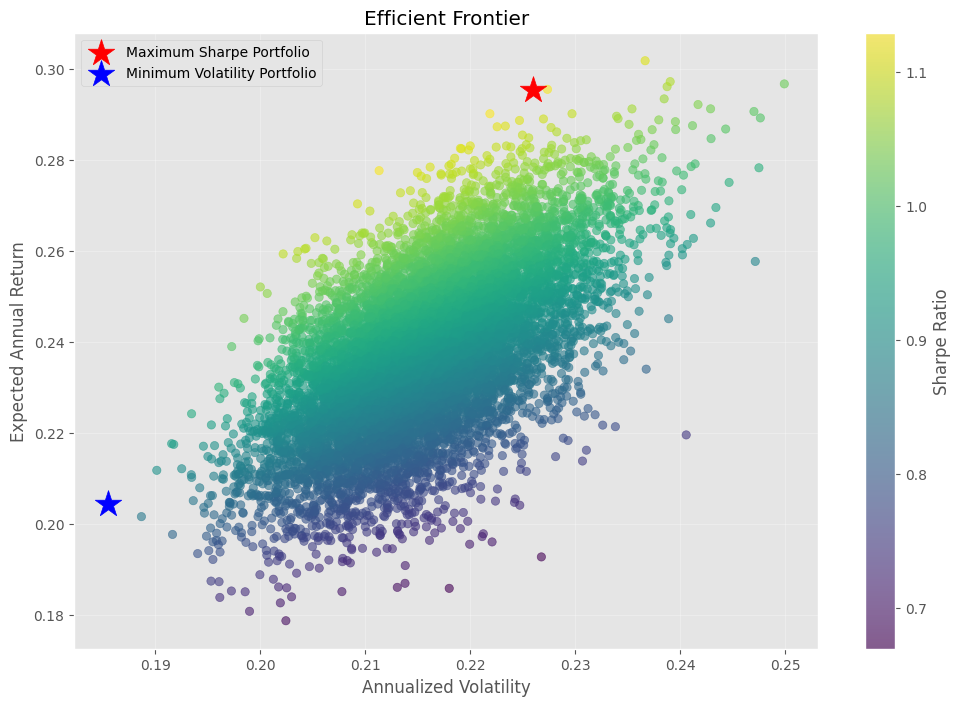

In [61]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    simulation_results["Volatility"],
    simulation_results["Return"],
    c=simulation_results["Sharpe Ratio"],
    alpha=0.6
)

plt.scatter(
    max_sharpe["Volatility"],
    max_sharpe["Return"],
    color="red",
    marker="*",
    s=400,
    label="Maximum Sharpe Portfolio"
)

plt.scatter(
    min_volatility["Volatility"],
    min_volatility["Return"],
    color="blue",
    marker="*",
    s=400,
    label="Minimum Volatility Portfolio"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")

plt.title("Efficient Frontier")

plt.legend()

plt.colorbar(scatter, label="Sharpe Ratio")

plt.grid(alpha=0.3)

plt.show()

# Next Steps: Building an Interactive Streamlit Dashboard

This notebook documents the complete analytical workflow behind a portfolio analysis and optimisation project using a diversified portfolio of 30 U.S. equities over a five-year period (2020–2025). Throughout the project, historical market data was used to analyse individual stock performance, construct an equally weighted portfolio, evaluate portfolio risk and return, and apply Modern Portfolio Theory through Monte Carlo simulation and the Efficient Frontier.

The primary objective of this project was to demonstrate the end-to-end process of portfolio analysis using Python from data collection and exploratory analysis to risk measurement and portfolio optimisation while applying widely used techniques in quantitative finance.

As a final extension, I intend to develop an interactive **Streamlit dashboard** that presents the project's key metrics, visualisations, and optimisation results in a clean, user-friendly interface. This will serve as the presentation layer of the project, complementing the analytical workflow documented throughout this notebook and showcasing the results in a more engaging format.

## Preparing Portfolio Data for Interactive Dashboard Deployment

The following code exports the key portfolio metrics, optimisation results, and risk measures generated throughout this analysis into a single serialized file (`portfolio_data.pkl`). This file serves as the data source for the accompanying Streamlit dashboard, allowing the interactive application to present the analysis without recomputing all calculations each time it is launched.

In [62]:
import pickle

dashboard_data = {

    # Portfolio performance
    "portfolio_returns": portfolio_returns,
    "portfolio_cumulative": portfolio_cumulative,

    # Risk
    "rolling_volatility": rolling_volatility,
    "drawdown": portfolio_drawdown,
    "max_drawdown": portfolio_drawdown.min(),

    # Summary metrics
    "expected_return": portfolio_return,
    "portfolio_volatility": portfolio_volatility,
    "sharpe_ratio": sharpe_ratio,
    "simulation_results": simulation_results,
    "equal_weighted_portfolio": equal_weighted_portfolio,

    # Optimization
    "optimized_portfolio": optimized_portfolio,
    "max_sharpe": max_sharpe,
    "min_volatility": min_volatility,

    # Allocation
    "best_weights": best_weights,

    # covariance
    "cov_matrix": cov_matrix
}

with open("portfolio_data.pkl", "wb") as f:
    pickle.dump(dashboard_data, f)


print("Dashboard data saved successfully!")

Dashboard data saved successfully!


In [63]:
optimized_portfolio

,Metric,Value
0,Expected Annual Return,0.295288
1,Annual Volatility,0.226013
2,Sharpe Ratio,1.129527


In [64]:
equal_weighted_portfolio

,Metric,Value
0,Expected Annual Return,0.237825
1,Annual Volatility,0.213993
2,Sharpe Ratio,0.924445
